# Python Lesson 44: Hessian Matrix

**Concept page:** `wiki/concepts/hessian-matrix.md` · **Area:** calculus

**You will be able to:**
- build H with SymPy
- classify critical points by eigenvalues
- identify minimum, maximum, saddle

*How to use:* run the cells top to bottom, read the output, then try the **Exercises** in the empty cells before opening the **Solutions** section at the bottom.

In [1]:
import numpy as np
import sympy as sp
import matplotlib
import matplotlib.pyplot as plt
np.set_printoptions(precision=4, suppress=True)
%matplotlib inline

## 1. Hessian of f=2x²+3y²−xy

In [2]:
x,y=sp.symbols('x y'); f=2*x**2+3*y**2-x*y
H=sp.hessian(f,(x,y)); print(H, H.eigenvals())

Matrix([[4, -1], [-1, 6]]) {5 - sqrt(2): 1, sqrt(2) + 5: 1}


## 2. Classifier

In [3]:
def classify(f):
    H=np.array(sp.hessian(f,(x,y)).subs({x:0,y:0}),float); w=np.linalg.eigvalsh(H)
    kind="minimum" if (w>0).all() else "maximum" if (w<0).all() else "saddle" if (w>0).any() and (w<0).any() else "inconclusive"
    return np.round(w,3),kind
for f in (2*x**2+3*y**2-x*y, -2*x**2-3*y**2-x*y+15, 2*x**2-2*y**2): print(f, classify(f))

2*x**2 - x*y + 3*y**2 (array([3.586, 6.414]), 'minimum')
-2*x**2 - x*y - 3*y**2 + 15 (array([-6.414, -3.586]), 'maximum')
2*x**2 - 2*y**2 (array([-4.,  4.]), 'saddle')


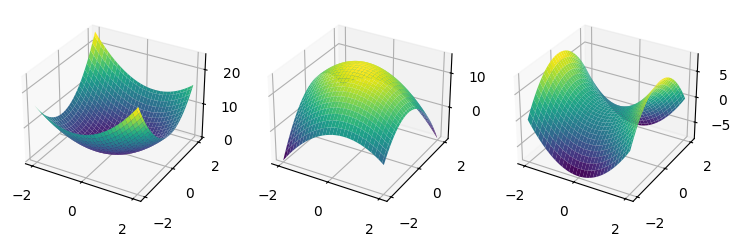

In [4]:
X,Y=np.meshgrid(np.linspace(-2,2,60),np.linspace(-2,2,60)); fig=plt.figure(figsize=(9,3))
for i,f in enumerate((2*x**2+3*y**2-x*y,-2*x**2-3*y**2-x*y+15,2*x**2-2*y**2)):
    ax=fig.add_subplot(1,3,i+1,projection='3d'); ax.plot_surface(X,Y,sp.lambdify((x,y),f,'numpy')(X,Y),cmap='viridis')
plt.show()

## Cambodian textbook corner (កម្មវិធីសិក្សាកម្ពុជា)
Textbooks classify extrema by the sign table of f' (one variable). The Hessian is the multi-variable version of f''.

In [5]:
print(classify(x**2+y**2))

(array([2., 2.]), 'minimum')


## Exercises

**Exercise 1.** Classify the critical point of f=x^2+xy+y^2 at the origin (minimum).

In [6]:
# your code here

**Exercise 2.** Show the Hessian of x^3 y^2 is symmetric.

In [7]:
# your code here

## Solutions
*(Try the exercises first!)*

In [8]:
# Solution 1
assert classify(x**2+x*y+y**2)[1]=='minimum'

In [9]:
# Solution 2
H=sp.hessian(x**3*y**2,(x,y)); assert H==H.T